## 🌸 EDA of MTJ Fragrance Dataset

MTJ Fragrance Dataset is a collection of fragrance products with various attributes. This EDA aims to explore the dataset, understand its structure, and identify any patterns or insights. ✨

In this dataset we have the following columns:
- **Title**: The name of the fragrance product. 🏷️
- **Price**: The price of the fragrance product (in `PKR`). 💰
- **URL**: The URL of the fragrance product. 🔗


## 📦 Cell 1: Importing Libraries
Here we load **pandas**, the core library for data manipulation in Python — our foundation for the entire EDA. 🚀


In [27]:
import pandas as pd

## 📂 Cell 2: Reading Raw CSV Pages
We read four separate CSV files (`page1.csv` through `page4.csv`) into individual DataFrames (`df0`–`df3`) to start gathering our perfume data. 🗂️


In [28]:
df0 = pd.read_csv('../data_scraping/page1.csv')
df1 = pd.read_csv('../data_scraping/page2.csv')
df2 = pd.read_csv('../data_scraping/page3.csv')
df3 = pd.read_csv('../data_scraping/page4.csv')

## 🔄 Cell 3: Automating File Loading & Concatenation
Using Python’s `glob` module, we grab **all** page\*.csv files, read them into a list of DataFrames, and then concatenate them into one master DataFrame `df`. No more copy-pasting! 🤖


In [ ]:
import glob
# Use glob to find all CSV files matching the pattern in the specified directory
# (Note: csv_files is already defined in previous cells)
csv_files = glob.glob('../data_scraping/page*.csv')

# Read each CSV file into a pandas DataFrame and store them in a list
# (Note: dfs is already defined in previous cells)
dfs = [pd.read_csv(f) for f in csv_files]

# Concatenate all DataFrames in the list into a single DataFrame
# (Note: df is already defined in previous cells)
df = pd.concat(dfs, ignore_index=True)


## 💾 Cell 4: Saving the Combined Dataset
We export our new `df` to `mtj_combined.csv` so you have a standalone, ready-to-use file for Kaggle or further analysis. 💽


In [ ]:
df.to_csv('../data_scraping/mtj_combined.csv', index=False)

## 👀 Cell 5: Peek at the Top of the Data
A quick look at the **first 5 rows** with `df.head()` to confirm our data loaded correctly and inspect key columns like “title” and “price.” 🔎


In [ ]:
# Head of the MTJ fragrance data
print(df.head())

                                               title      price  \
0  THE PERSIAN COLLECTION DISCOVERY KIT | 3 Fragr...  PKR 2,280   
1  ORIENTAL COLLECTION DISCOVERY SET | 5 Fragranc...  PKR 2,780   
2   HIMALAYAN INSPIRATIONS (3 Fragrances + Atomizer)  PKR 2,280   
3  THE GOLD COLLECTION DISCOVERY SET | 3 Fragranc...  PKR 2,280   
4                                              FATEH  PKR 4,990   

                                                 url  
0  https://mtjonline.com/collections/fragrances/p...  
1  https://mtjonline.com/collections/fragrances/p...  
2  https://mtjonline.com/collections/fragrances/p...  
3  https://mtjonline.com/collections/fragrances/p...  
4  https://mtjonline.com/collections/fragrances/p...  


## 👇 Cell 6: Peek at the Bottom of the Data
Similarly, `df.tail()` shows the **last 5 rows**, helping verify there's no weird footer or incomplete trailing entries. 👍


In [ ]:
# Tail of the MTJ fragrance data
print(df.tail())

                   title      price  \
88  HIMALAYAN MUSK-ATTAR  PKR 2,990   
89                 ZIRAN  PKR 1,550   
90                FLORIS  PKR 1,550   
91                SOLACE  PKR 1,550   
92               REEFEST  PKR 1,550   

                                                  url  
88  https://mtjonline.com/collections/fragrances/p...  
89  https://mtjonline.com/collections/fragrances/p...  
90  https://mtjonline.com/collections/fragrances/p...  
91  https://mtjonline.com/collections/fragrances/p...  
92  https://mtjonline.com/collections/fragrances/p...  


## 🗂️ Cell 7: Checking Column Data Types
`df.dtypes` reveals each column’s type (e.g., `object` vs. `float64`), so we know which fields need cleaning or conversion. 📊


In [ ]:
# The Dataset Columns Types
print(df.dtypes)

title    object
price    object
url      object
dtype: object


## ℹ️ Cell 8: Full Dataset Summary
Calling `df.info()` gives us non-null counts and memory usage — key for spotting missing data or unexpected large memory footprints. 📈


In [ ]:
# The Dataset over all information
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   93 non-null     object
 1   price   93 non-null     object
 2   url     93 non-null     object
dtypes: object(3)
memory usage: 2.3+ KB
None


## ❓ Cell 9: Identifying Missing Values
`df.isnull().sum()` tells us exactly how many nulls live in each column, letting us plan imputation or row drops. 🧹


In [ ]:
# Checking Missing Values
print(df.isnull().sum())

title    0
price    0
url      0
dtype: int64


## 🔍 Cell 10: Detecting Duplicates
We check `df.duplicated().sum()` to see if any perfumes appear more than once and need deduplication. 🕵️‍♂️


In [ ]:
# Checking for Duplicates
print(df.duplicated().sum())

0


## 💰 Cell 11: Cleaning the Price Column
Here we strip out “PKR” and commas from `df['price']` and convert it to `float`. Then we re-print `df.dtypes` to confirm the change. ✨


In [39]:
# Remove the PKR symbol from the 'Price' column and convert it to numeric
df['price'] = df['price'].replace({'PKR': '', ',': ''}, regex=True).astype(float)
df.dtypes

title             object
price            float64
url               object
price_numeric    float64
dtype: object

## 💎 Cell 12: Finding Price Extremes % Lowest
We locate and **print** the single most expensive and least expensive perfumes to get immediate insight into price range. 🎯

- **Most Expensive Perfume:**  
    The highest-priced perfume is **GOLD COLLECTION BOX** at **Rs 15,900**.

- **Cheapest Perfumes:**  
    The lowest price is **Rs 850**, shared by several perfumes including **ALMOND DELIGHT**, **WILDFLOWER**, **INFINITE JOY**, **BONBONLIME**, **QUEEN OF HEARTS**, **ORIENT EXPRESS**, **ALMOST PARADISE**, and **WALK ON THE MOON**.


In [41]:
# MTJ Fragrance Most Expensive Perfume
# print the maximum price of the perfume with name
max_price = df[df['price'] == df['price'].max()]
print(f"Max price perfume: {max_price['title'].values[0]} : Rs {max_price['price'].values[0]}\n")

# print the minimum price of the perfume with name
min_price = df[df['price'] == df['price'].min()]
print(f"Min price perfume: {min_price['title'].values[0]} : Rs {min_price['price'].values[0]}\n")

Max price perfume: GOLD COLLECTION BOX : Rs 15900.0

Min price perfume: ALMOND DELIGHT : Rs 850.0



## 🌿 Cell 13: Counting “ATTAR” Perfumes
Using a string filter on the `title`, we count how many contain “ATTAR” — a common fragrance type. 🧴


In [47]:
# MTJ Fragrance ATTAR Perfumes
df_oud = df[df['title'].str.contains('ATTAR', case=False, na=False)]
print(f"Total number of perfumes with 'ATTAR': {len(df_oud)}\n")

Total number of perfumes with 'ATTAR': 10



## 🏠 Cell 14: Counting “Room Spray” Products
Similarly, we filter titles for “Room Spray” to see how many home-fragrance items are present. 🏡


In [60]:
# MTJ Fragrance Room Spray Perfumes
df_room_spray = df[df['title'].str.contains('Room Spray', case=False, na=False)]
print(f"Total number of perfumes with 'Room Spray': {len(df_room_spray)}\n")

Total number of perfumes with 'Room Spray': 4



## 📈 Cell 15: Top 10 Most Expensive Perfumes
We plot a **bar chart** of the 10 priciest perfumes using Matplotlib & Seaborn, complete with annotations showing actual prices. 💸


C:\Users\touse\AppData\Local\Temp\ipykernel_6212\2088060804.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='title', data=df.nlargest(10, 'price'), palette='plasma')


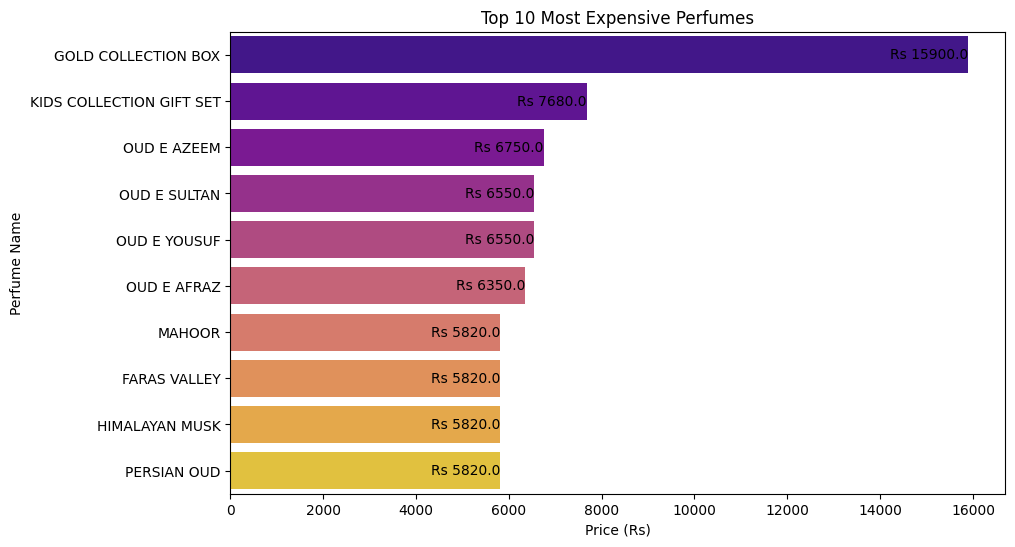

In [56]:
# Top 10 Most Expensive Perfumes
# Create a bar plot of the top 10 perfumes with the highest price using mateplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Set the figure size
plt.figure(figsize=(10, 6))
# Create a bar plot
sns.barplot(x='price', y='title', data=df.nlargest(10, 'price'), palette='plasma') 
# Set the title and labels
plt.title('Top 10 Most Expensive Perfumes')
plt.xlabel('Price (Rs)')
plt.ylabel('Perfume Name')
# add anotation
for index, value in enumerate(df.nlargest(10, 'price')['price']):
    plt.text(value, index, f'Rs {value}', va='center', ha='right', fontsize=10)
# Show the plot
plt.show()

## 💸 Cell 16: Top 10 Cheapest Perfumes
Finally, we chart the **10 least expensive** perfumes in a similar style, giving a full view of budget-friendly options. 🛍️


C:\Users\touse\AppData\Local\Temp\ipykernel_6212\2083945906.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='title', data=df.nsmallest(10, 'price'), palette='viridis')


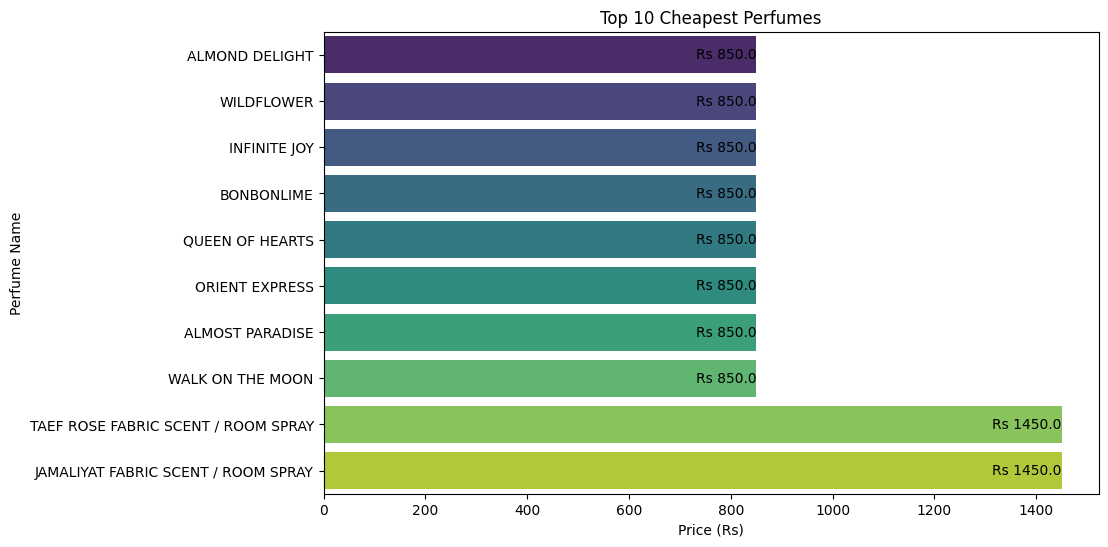

In [59]:
# MTJ top 10 Most Cheapest Perfumes
# create a bar plot of the top 10 perfumes with the lowest price using mateplotlib
# Set the figure size
plt.figure(figsize=(10, 6))
# Create a bar plot
sns.barplot(x='price', y='title', data=df.nsmallest(10, 'price'), palette='viridis')
# Set the title and labels
plt.title('Top 10 Cheapest Perfumes')
plt.xlabel('Price (Rs)')
plt.ylabel('Perfume Name')
# add anotation
for index, value in enumerate(df.nsmallest(10, 'price')['price']):
    plt.text(value, index, f'Rs {value}', va='center', ha='right', fontsize=10)
# Show the plot
plt.show()